# 02 — Spectrum analysis

This notebook focuses on the main analysis spectrum export.

It demonstrates:

- metadata inspection
- ROI / mass peak list inspection
- mass-vs-channel calibration
- linear and logarithmic spectrum plotting
- basic plotting windows using `xlim`

In [8]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from pymagsims import spectrum
from pymagsims.spectrum import Spectrum

DATA = Path("../data")
spec = Spectrum.from_main_analysis_file(DATA / "FPD_01_2604281458290.csv")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Metadata and ROI table

In [9]:
display(spec.metadata)
display(spec.roi_table)

{'file_information': {'Type': 'DLD_MS',
  'Date': '4/28/2026 3:07:49 PM',
  'Version': None},
 'analysis_parameters': {'Integration time (ms)': 1000,
  'Size': 256,
  'Cumulative acquisitions': 200,
  'Readback magnetic field (mT)': 401,
  'Control magnetic field (mT)': 398},
 'sims_metrics': {'Polarity': 'Positive',
  'Sample bias': 500,
  'Inner sphere': 358.7,
  'Outer sphere': 422,
  'Exit': 398.8,
  'Side plates': 290,
  'BEND inner': 560,
  'BEND outer': 560,
  'Acceleration': 3000,
  'Lens1': 1787,
  'Lens2': 2165,
  'Lens3': 1335,
  'Quadrupole 1X': 3,
  'Quadrupole 1Y': 2.4,
  'Quadrupole 2X': -0.6,
  'Quadrupole 2Y': -3.3,
  'Quadrupole 3X': 2.1,
  'Quadrupole 3Y': -1.2,
  'Quadrupole 4X': -5.5,
  'Quadrupole 4Y': -3,
  'ESA inner': 780,
  'ESA outer': 680,
  'TIC': 2200,
  'Anode': 2600,
  'Aperture': '400um',
  'X extraction': 60.167,
  'Y extraction': 0.815},
 'platform_metrics': {'x (mm)': -2.20363,
  'y (mm)': 2.10207,
  'z (mm)': 5.824375,
  'r (°)': 0.01296,
  't (°)':

,Color,Name,Mass,CH min,CH max,Mass min,Mass max,Integration,Max,FWHM
0,0,Total,0,0,10000,1.697456,126.608148,3659009,99392,0.291392


## Spectrum data

In [3]:
display(spec.data.head())
display(spec.data.describe())

,Channel,Mass,Amplitude
0,1,1.700559,6.0
1,2,1.703664,8.0
2,3,1.706771,7.0
3,4,1.709879,8.0
4,5,1.712990,10.0


,Channel,Mass,Amplitude
count,12000.00000,12000.000000,12000.000000
mean,6000.50000,65.384379,305.005083
std,3464.24595,50.790303,3301.877670
min,1.00000,1.700559,0.000000
25%,3000.75000,19.460533,2.000000
50%,6000.50000,54.117703,11.000000
75%,9000.25000,105.672073,54.000000
max,12000.00000,174.123638,99392.000000


## Channel-to-mass calibration

Text(0.5, 1.0, 'Mass calibration: mass vs detector channel')

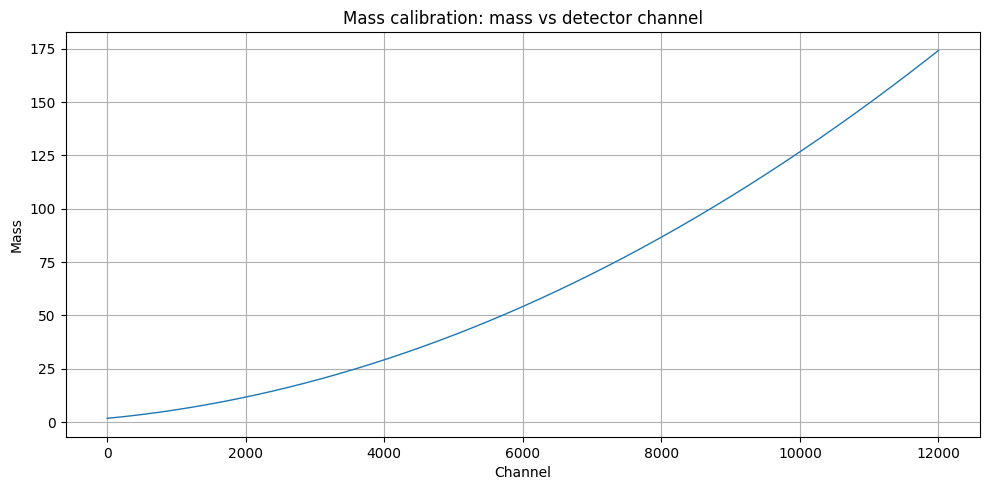

In [4]:
fig, ax = spec.plot(x="Channel", y="Mass", log_y=False)
ax.set_title("Mass calibration: mass vs detector channel")

## Spectrum on a linear scale

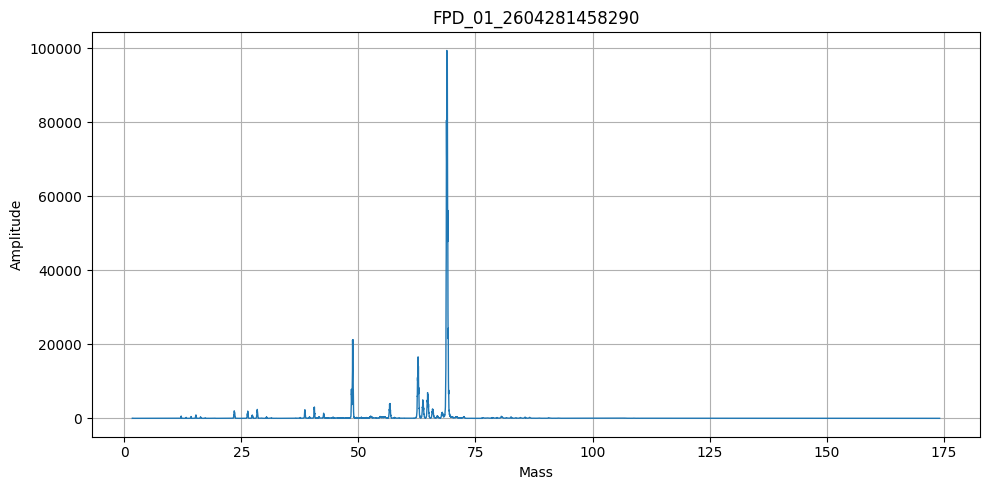

In [5]:
spec.plot(x="Mass", y="Amplitude", log_y=False);

## Spectrum on a logarithmic scale

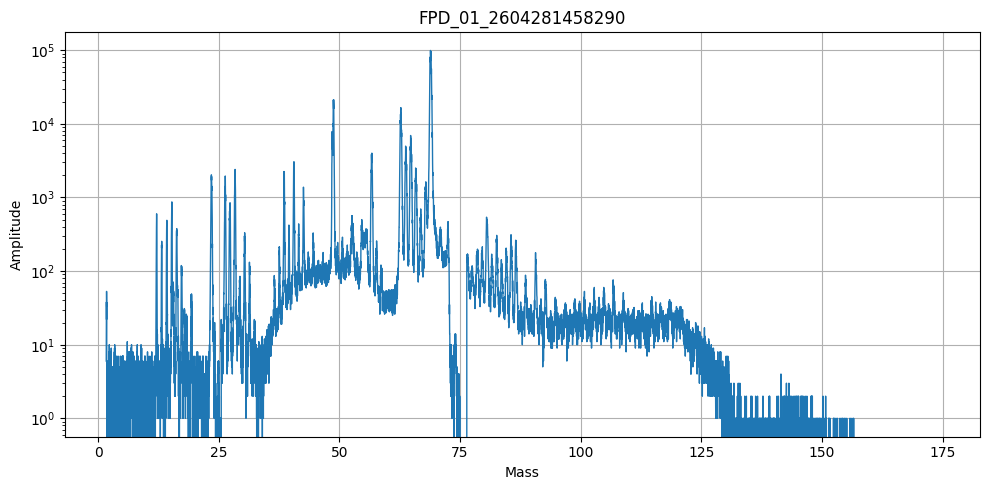

In [6]:
spec.plot(x="Mass", y="Amplitude", log_y=True);

## Zoom into a selected mass region

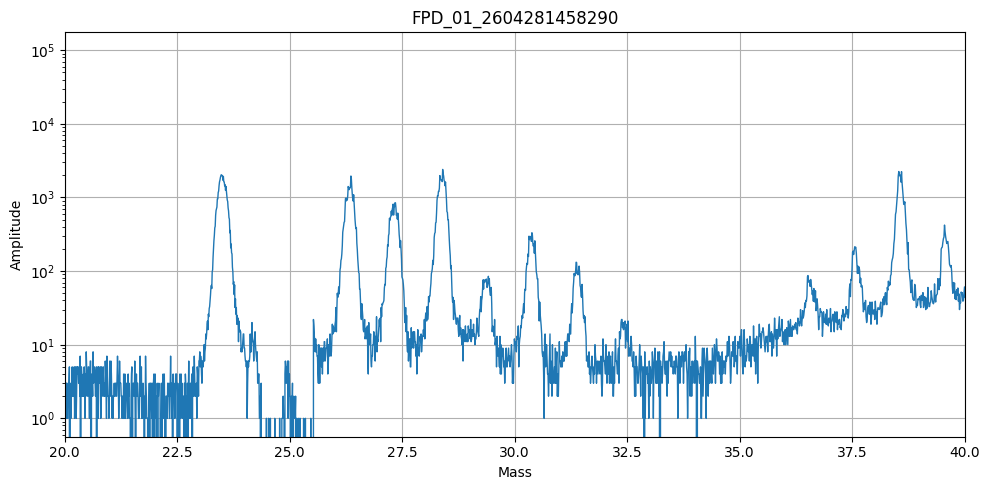

In [7]:
spec.plot(x="Mass", y="Amplitude", log_y=True, xlim=(20, 40));